In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

In [24]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

X_train = train_df.drop("Activity", axis=1)
X_test = test_df.drop("Activity", axis=1)
y_train = train_df["Activity"]
y_test = test_df["Activity"]


In [25]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), str(1)
memory usage: 31.6 MB


In [26]:
train_df.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject
count,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,...,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000
mean,0.274488,-0.017695,-0.109141,-0.605438,-0.510938,-0.604754,-0.630512,-0.526907,-0.606150,-0.468604,...,-0.307009,-0.625294,0.008684,0.002186,0.008726,-0.005981,-0.489547,0.058593,-0.056515,17.413085
std,0.070261,0.040811,0.056635,0.448734,0.502645,0.418687,0.424073,0.485942,0.414122,0.544547,...,0.321011,0.307584,0.336787,0.448306,0.608303,0.477975,0.511807,0.297480,0.279122,8.975143
min,-1.000000,-1.000000,-1.000000,-1.000000,-0.999873,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-0.995357,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
25%,0.262975,-0.024863,-0.120993,-0.992754,-0.978129,-0.980233,-0.993591,-0.978162,-0.980251,-0.936219,...,-0.542602,-0.845573,-0.121527,-0.289549,-0.482273,-0.376341,-0.812065,-0.017885,-0.143414,8.000000
50%,0.277193,-0.017219,-0.108676,-0.946196,-0.851897,-0.859365,-0.950709,-0.857328,-0.857143,-0.881637,...,-0.343685,-0.711692,0.009509,0.008943,0.008735,-0.000368,-0.709417,0.182071,0.003181,19.000000
75%,0.288461,-0.010783,-0.097794,-0.242813,-0.034231,-0.262415,-0.292680,-0.066701,-0.265671,-0.017129,...,-0.126979,-0.503878,0.150865,0.292861,0.506187,0.359368,-0.509079,0.248353,0.107659,26.000000
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,1.000000,0.478157,1.000000,30.000000


In [27]:
print(f"Training set shape:", train_df.shape)
print(f"Testing set shape:", test_df.shape)
print(f"Number of activities:", train_df['Activity'].nunique())
print(f"Activities:", train_df['Activity'].unique())

Training set shape: (7352, 563)
Testing set shape: (2947, 563)
Number of activities: 6
Activities: <ArrowStringArray>
[          'STANDING',            'SITTING',             'LAYING',
            'WALKING', 'WALKING_DOWNSTAIRS',   'WALKING_UPSTAIRS']
Length: 6, dtype: str


Check for nulls

In [28]:
train_df.isna().sum()

tBodyAcc-mean()-X       0
tBodyAcc-mean()-Y       0
tBodyAcc-mean()-Z       0
tBodyAcc-std()-X        0
tBodyAcc-std()-Y        0
                       ..
angle(X,gravityMean)    0
angle(Y,gravityMean)    0
angle(Z,gravityMean)    0
subject                 0
Activity                0
Length: 563, dtype: int64

Check for duplicates

In [29]:
train_df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7347    False
7348    False
7349    False
7350    False
7351    False
Length: 7352, dtype: bool

In [30]:
print(f"Total missing values:", train_df.isna().sum().sum())
print(f"Total duplicate rows:", train_df.duplicated().sum())

Total missing values: 0
Total duplicate rows: 0


The dataset has 561 features which is too many to visualize clearly.
12 representative features have been selected  — one from each sensor type and axis — to use for visualization purposes.

In [31]:
representative_features = [
    # Accelerometer (Body Movement)
    'tBodyAcc-mean()-X',
    'tBodyAcc-mean()-Y',
    'tBodyAcc-mean()-Z',
    # Gyroscope (Rotation)
    'tBodyGyro-mean()-X',
    'tBodyGyro-mean()-Y',
    'tBodyGyro-mean()-Z',
    # Gravity
    'tGravityAcc-mean()-X',
    'tGravityAcc-mean()-Y',
    'tGravityAcc-mean()-Z',
    # Magnitude (Overall Strength)
    'tBodyAccMag-mean()',
    'tBodyGyroMag-mean()',
    'tBodyAccJerkMag-mean()'
]

Sensor Signal Visualization (three features as example):

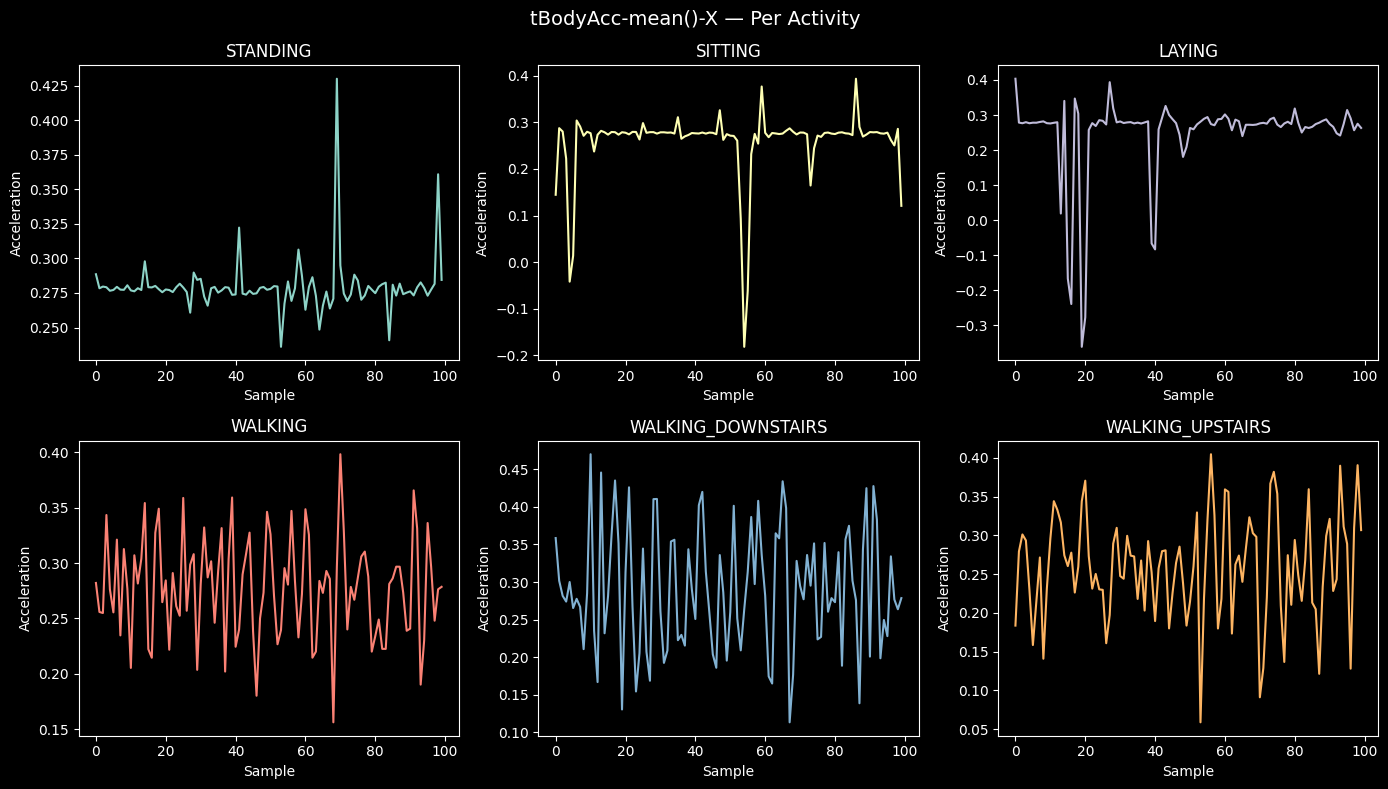

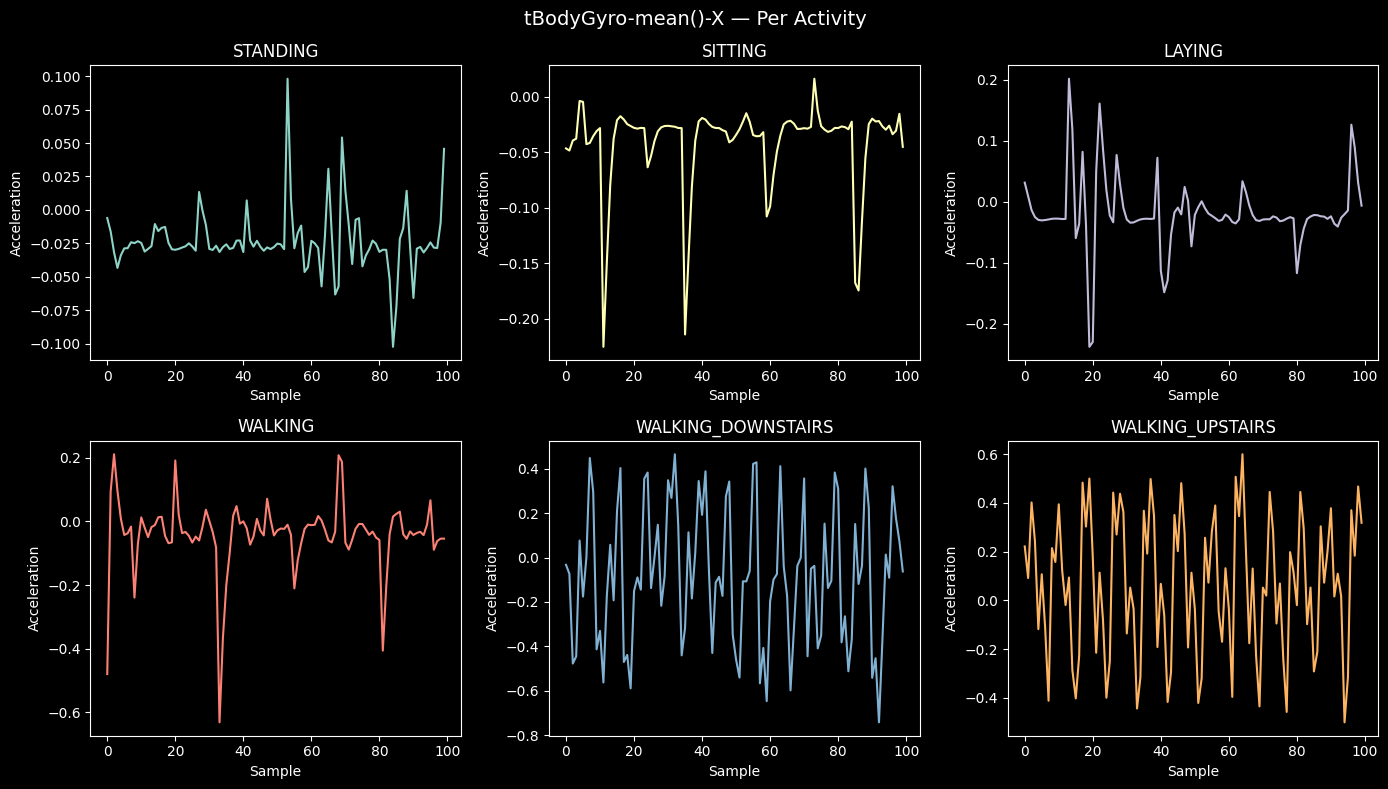

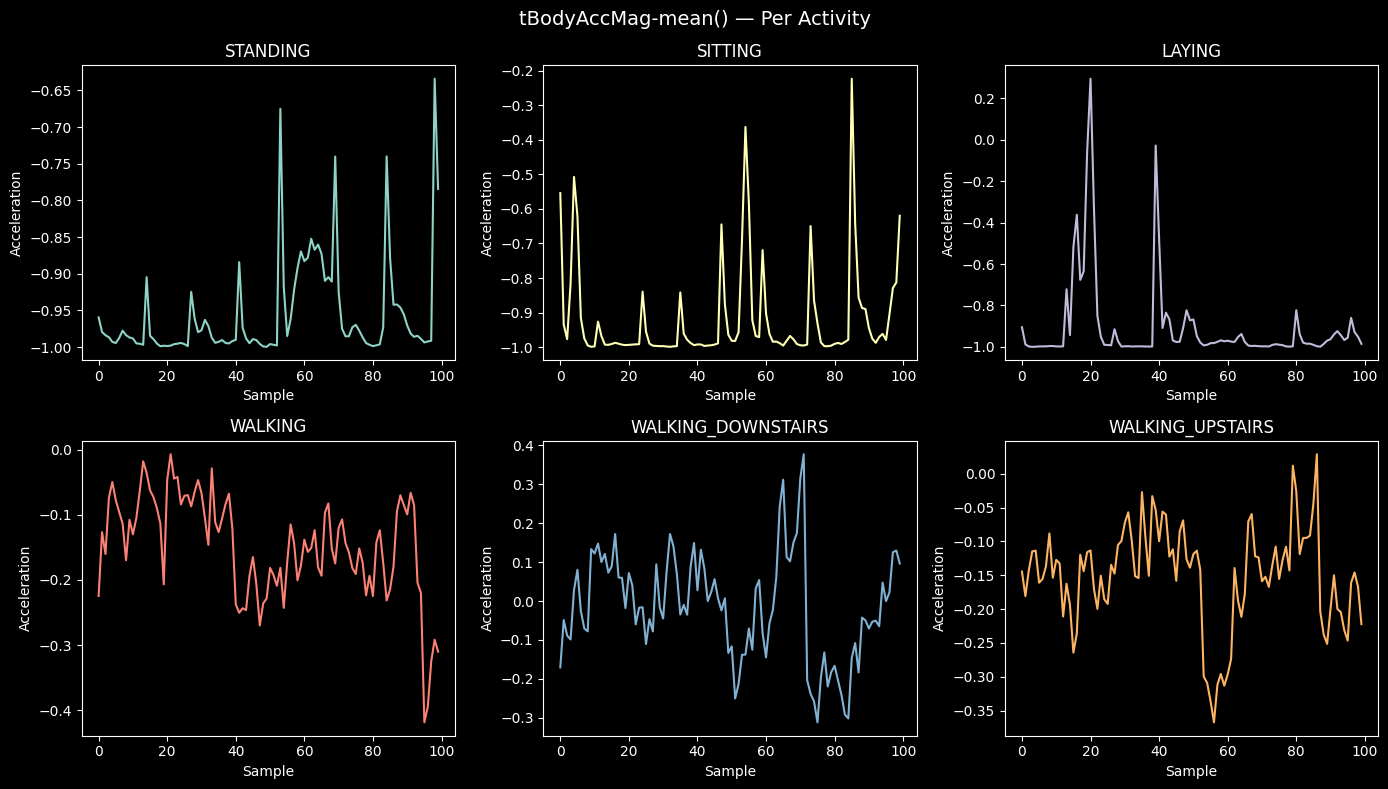

In [32]:
features = ['tBodyAcc-mean()-X', 'tBodyGyro-mean()-X', 'tBodyAccMag-mean()']
for j in range(len(features)):
    plt.figure(figsize=(14, 8))
    for i, activity in enumerate(train_df['Activity'].unique()):
        subset = train_df[train_df['Activity'] == activity]
        plt.subplot(2, 3, i+1)
        plt.plot(subset[features[j]].values[:100], color=f'C{i}')
        plt.title(activity)
        plt.xlabel('Sample')
        plt.ylabel('Acceleration')

    plt.suptitle(f'{features[j]} — Per Activity', fontsize=14)
    plt.tight_layout()
    plt.show()

Feature Distribution per Activity:

KDE (Kernel Density Estimation) plots are used to visualize how the values of each feature are distributed for each activity.

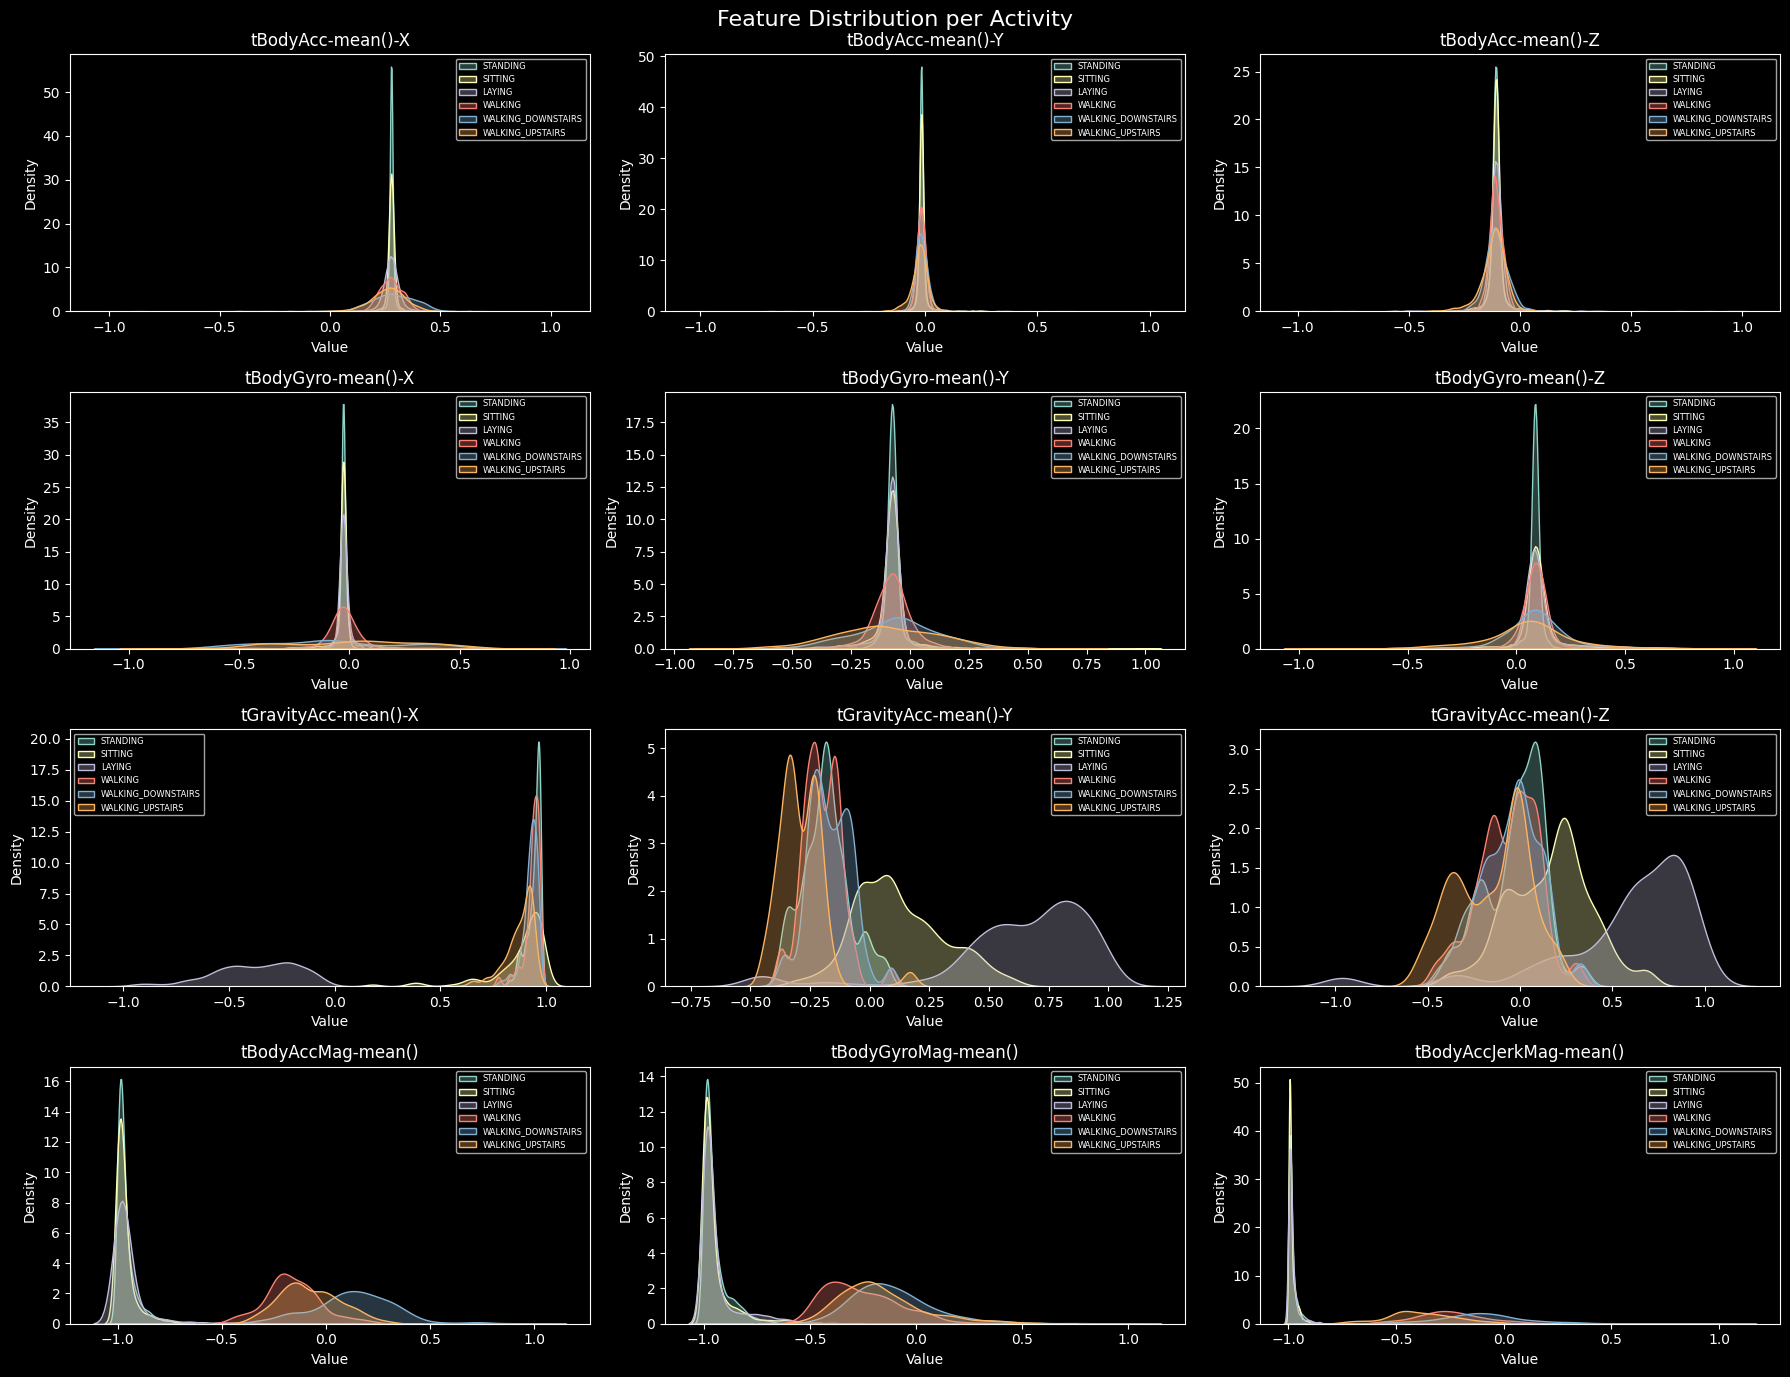

In [33]:
plt.figure(figsize=(18, 14))

for i, feature in enumerate(representative_features):
    plt.subplot(4, 3, i+1)

    for activity in train_df['Activity'].unique():
        subset = train_df[train_df['Activity'] == activity]
        sns.kdeplot(subset[feature],
                   label=activity,
                   fill=True,
                   alpha=0.3)

    plt.title(feature)
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend(fontsize=6)

plt.suptitle('Feature Distribution per Activity', fontsize=16)
plt.tight_layout()
plt.show()

Boxplot Analysis:

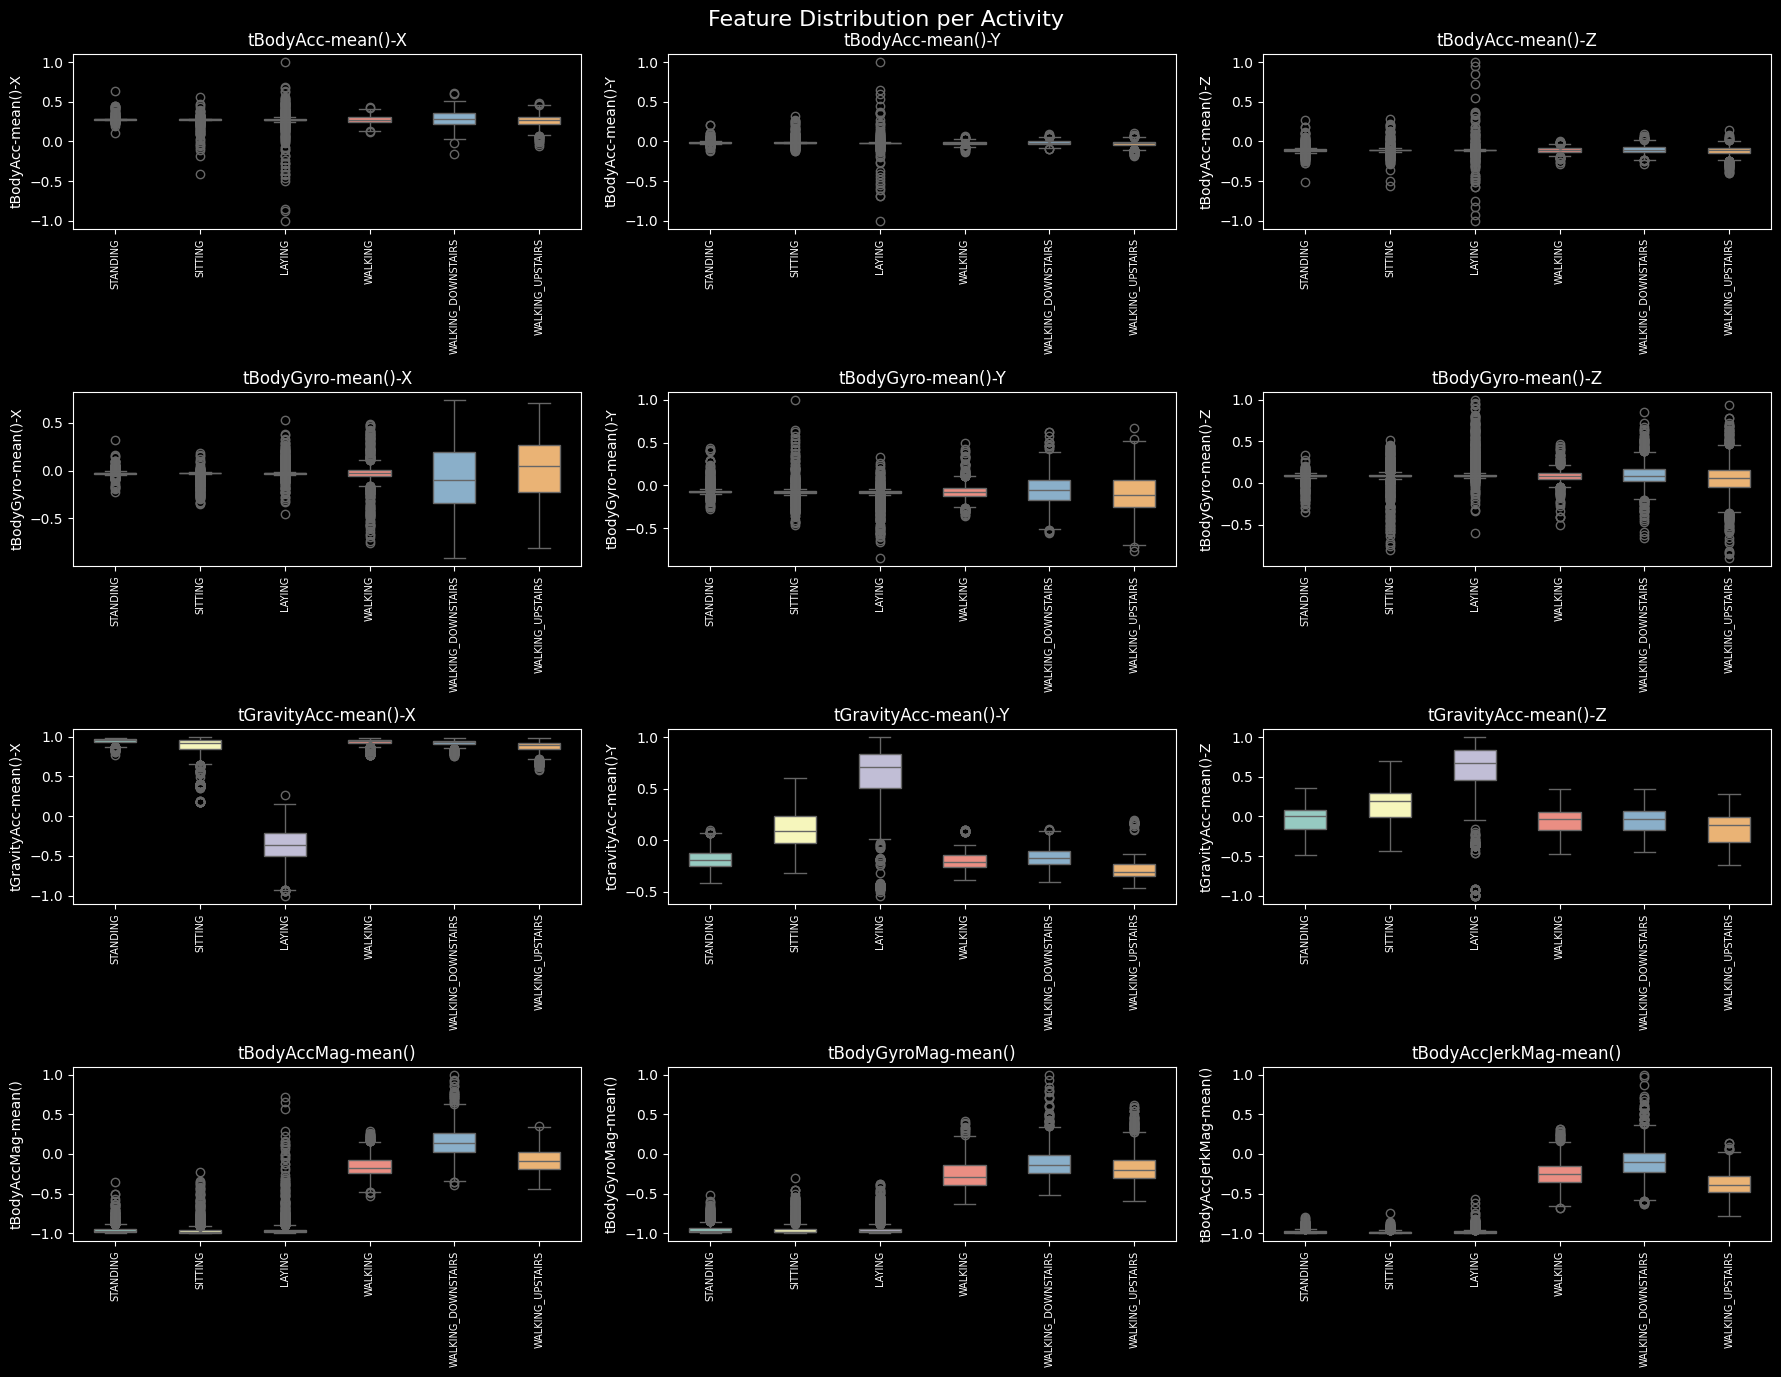

In [34]:
plt.figure(figsize=(18, 14))

for i, feature in enumerate(representative_features):
    plt.subplot(4, 3, i+1)

    sns.boxplot(data=train_df,
                x='Activity',
                y=feature,
                palette='Set3',
                width=0.5,
                hue='Activity',
                legend=False)

    plt.title(feature)
    plt.xticks(rotation=90, fontsize=7)
    plt.xlabel('')

plt.suptitle('Feature Distribution per Activity', fontsize=16)
plt.tight_layout()
plt.show()

Check outliers per activity

checking for outliers using the IQR method.
Important note: we check outliers within each activity separately,
not across the whole dataset. This is because different activities
have naturally different value ranges — mixing them would make
normal walking values appear as outliers in the sitting group

In [35]:
results = {}

for activity in train_df['Activity'].unique():
    subset = train_df[train_df['Activity'] == activity][representative_features]

    Q1 = subset.quantile(0.25)
    Q3 = subset.quantile(0.75)
    IQR = Q3 - Q1

    outliers = ((subset < (Q1 - 1.5 * IQR)) |
                (subset > (Q3 + 1.5 * IQR)))

    results[activity] = outliers.sum().sum()

for activity, count in results.items():
    print(f"{activity}: {count} outliers")

STANDING: 1643 outliers
SITTING: 2216 outliers
LAYING: 2573 outliers
WALKING: 550 outliers
WALKING_DOWNSTAIRS: 303 outliers
WALKING_UPSTAIRS: 355 outliers


Bar chart of outliers per activity

Static activities (sitting, standing, laying):

When you're sitting still, your sensor readings are mostly flat and stable. So even a tiny movement — like shifting in your chair, breathing deeply, or slightly adjusting your posture — looks like an "outlier" to the IQR method because it's so different from the flat stable signal.

Dynamic activities (walking):

When you're walking, your sensor readings are constantly changing up and down. So the IQR range is already wide enough to accommodate most movements — fewer values fall outside it.

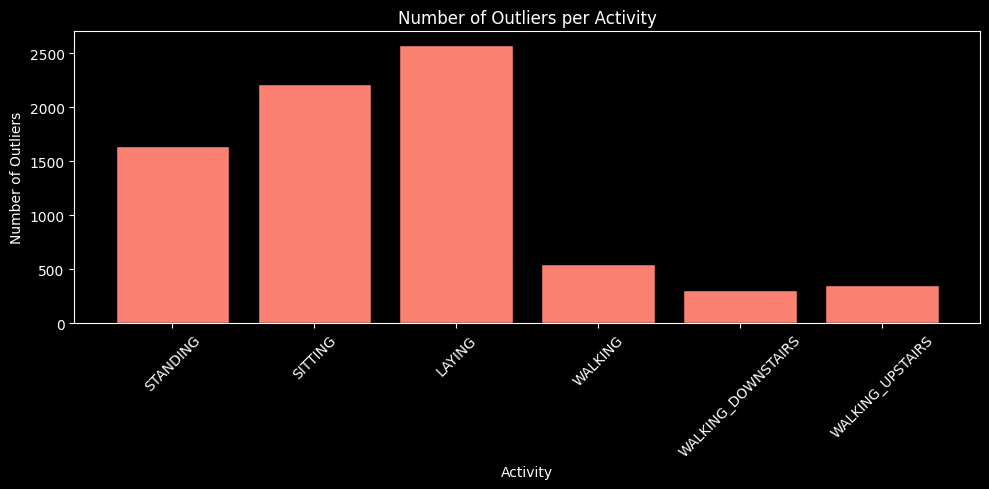

In [36]:
plt.figure(figsize=(10, 5))
plt.bar(results.keys(),
        results.values(),
        color='salmon',
        edgecolor='black')
plt.title('Number of Outliers per Activity')
plt.xlabel('Activity')
plt.ylabel('Number of Outliers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Correlation Analysis

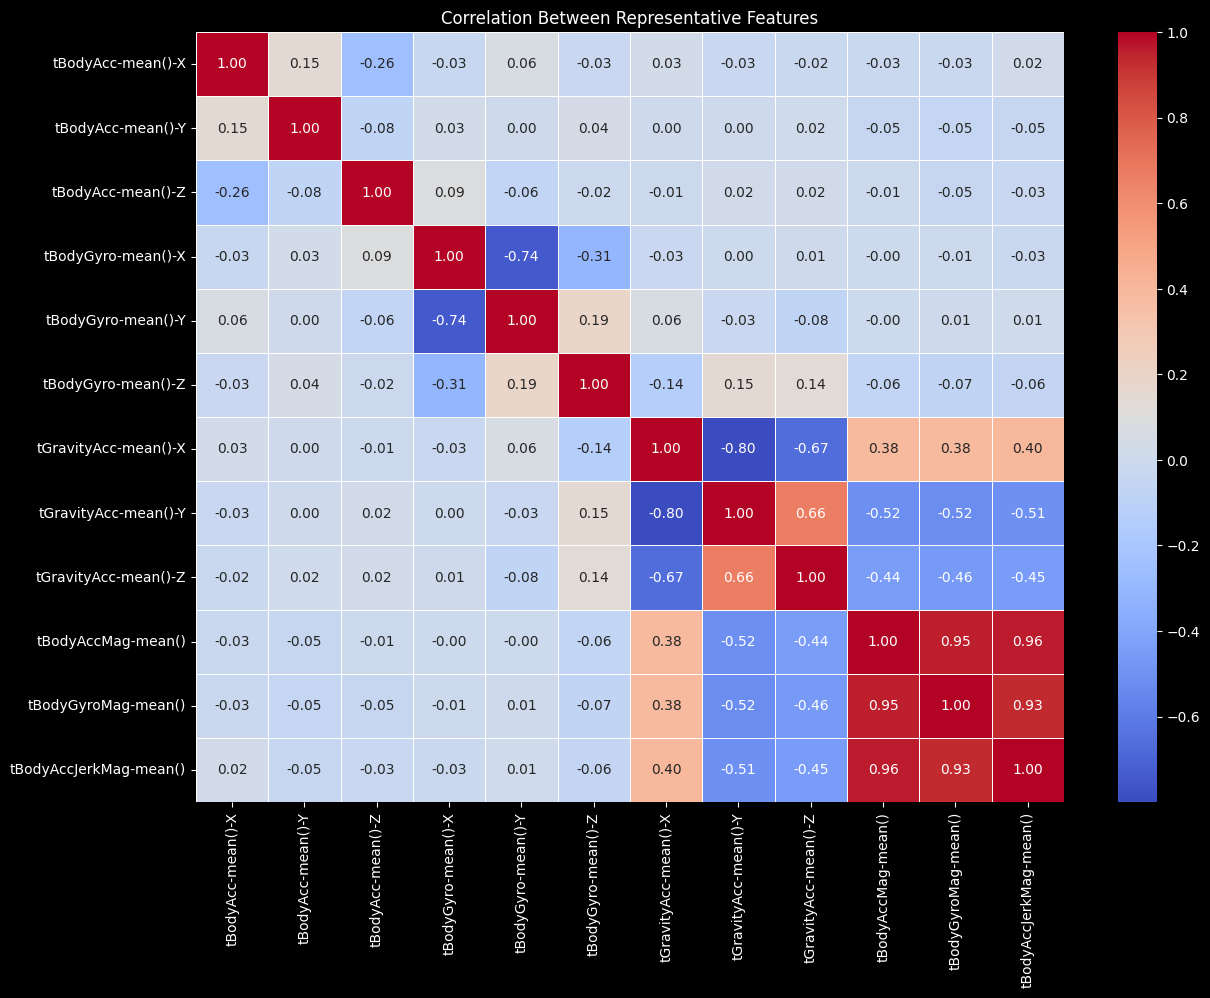

In [37]:
plt.figure(figsize=(14, 10))
sns.heatmap(train_df[representative_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Between Representative Features')
plt.show()

Calculate the Mean and visualize it:

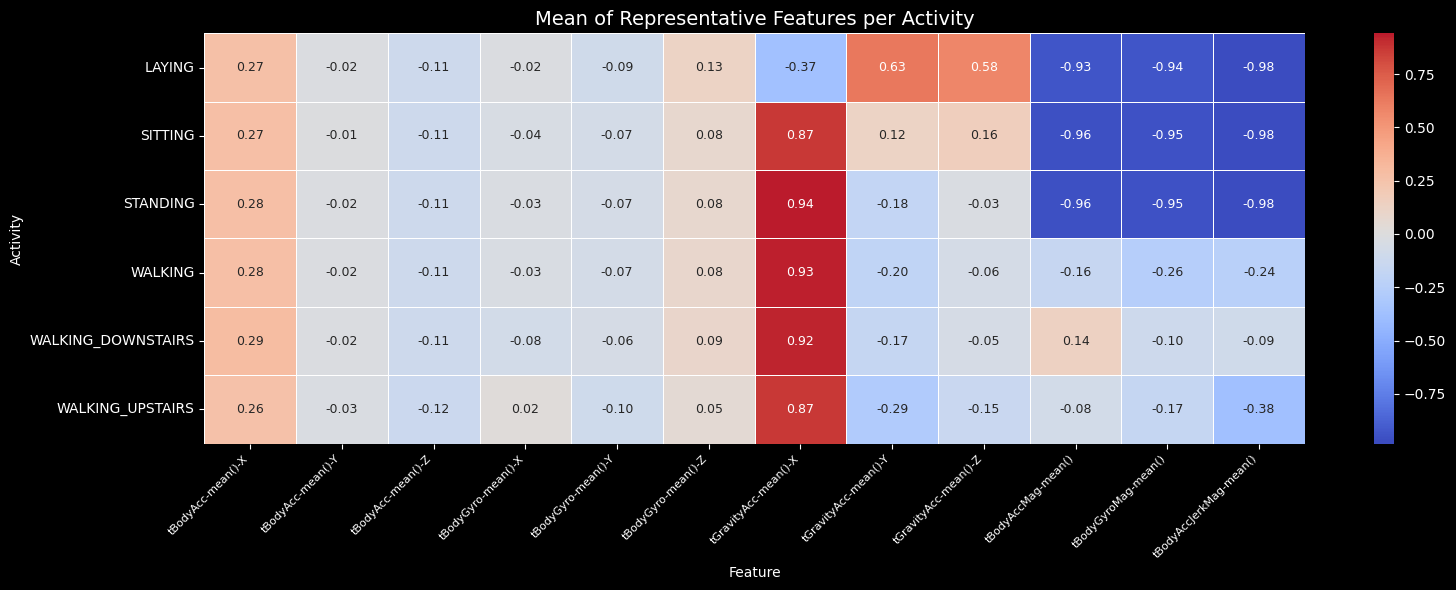

In [38]:
plt.figure(figsize=(16, 6))

mean_data = train_df.groupby('Activity')[representative_features].mean()

sns.heatmap(mean_data,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            annot_kws={'size': 9})

plt.title('Mean of Representative Features per Activity', fontsize=14)
plt.xlabel('Feature')
plt.ylabel('Activity')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

Calculate the Standard Deviation and visualize it:

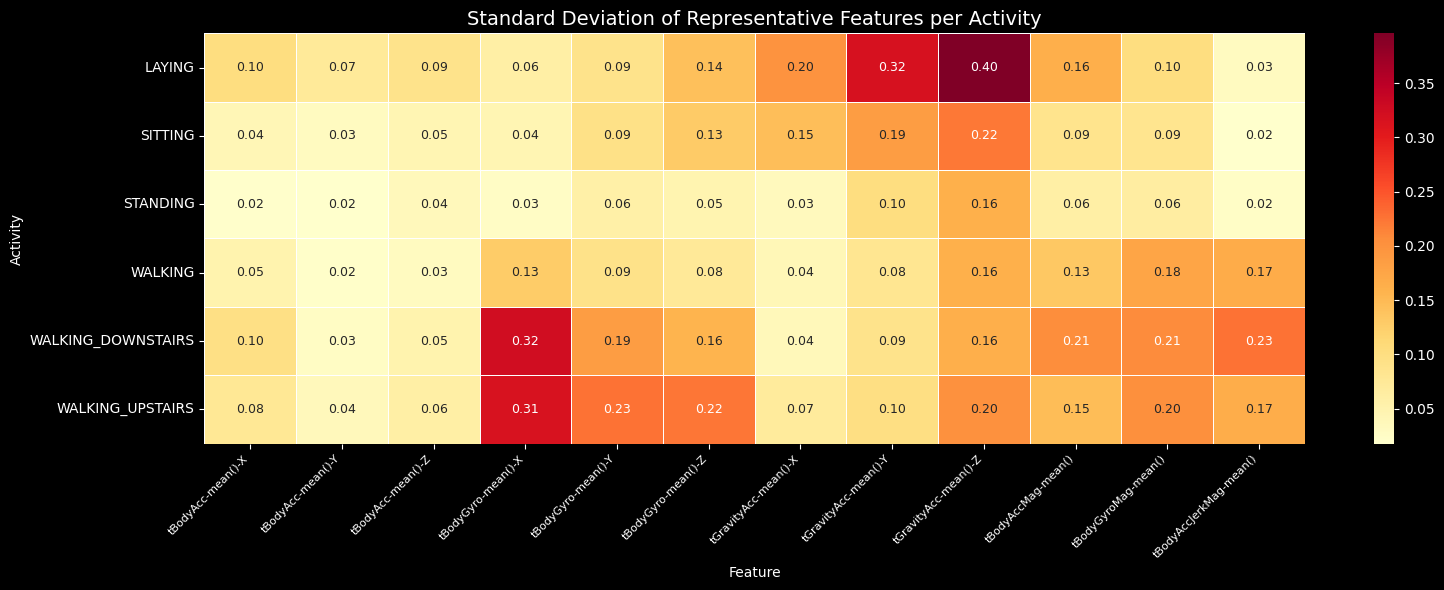

In [39]:
plt.figure(figsize=(16, 6))

std_data = train_df.groupby('Activity')[representative_features].std()

sns.heatmap(std_data,
            annot=True,
            fmt='.2f',
            cmap='YlOrRd',
            linewidths=0.5,
            annot_kws={'size': 9})

plt.title('Standard Deviation of Representative Features per Activity', fontsize=14)
plt.xlabel('Feature')
plt.ylabel('Activity')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

Calculate the Skewness and visualize it:

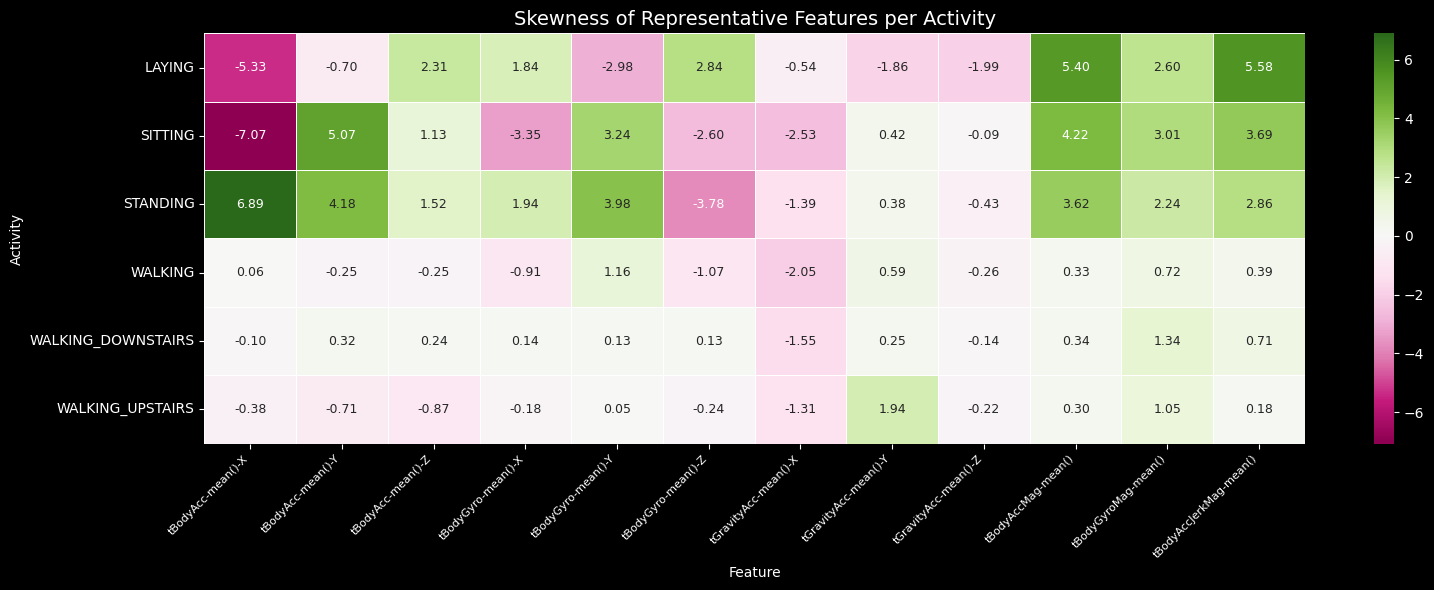

In [40]:
plt.figure(figsize=(16, 6))

skew_data = train_df.groupby('Activity')[representative_features].skew()

sns.heatmap(skew_data,
            annot=True,
            fmt='.2f',
            cmap='PiYG',
            center=0,
            linewidths=0.5,
            annot_kws={'size': 9})

plt.title('Skewness of Representative Features per Activity', fontsize=14)
plt.xlabel('Feature')
plt.ylabel('Activity')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

Frequency Domain Analysis (FFT):

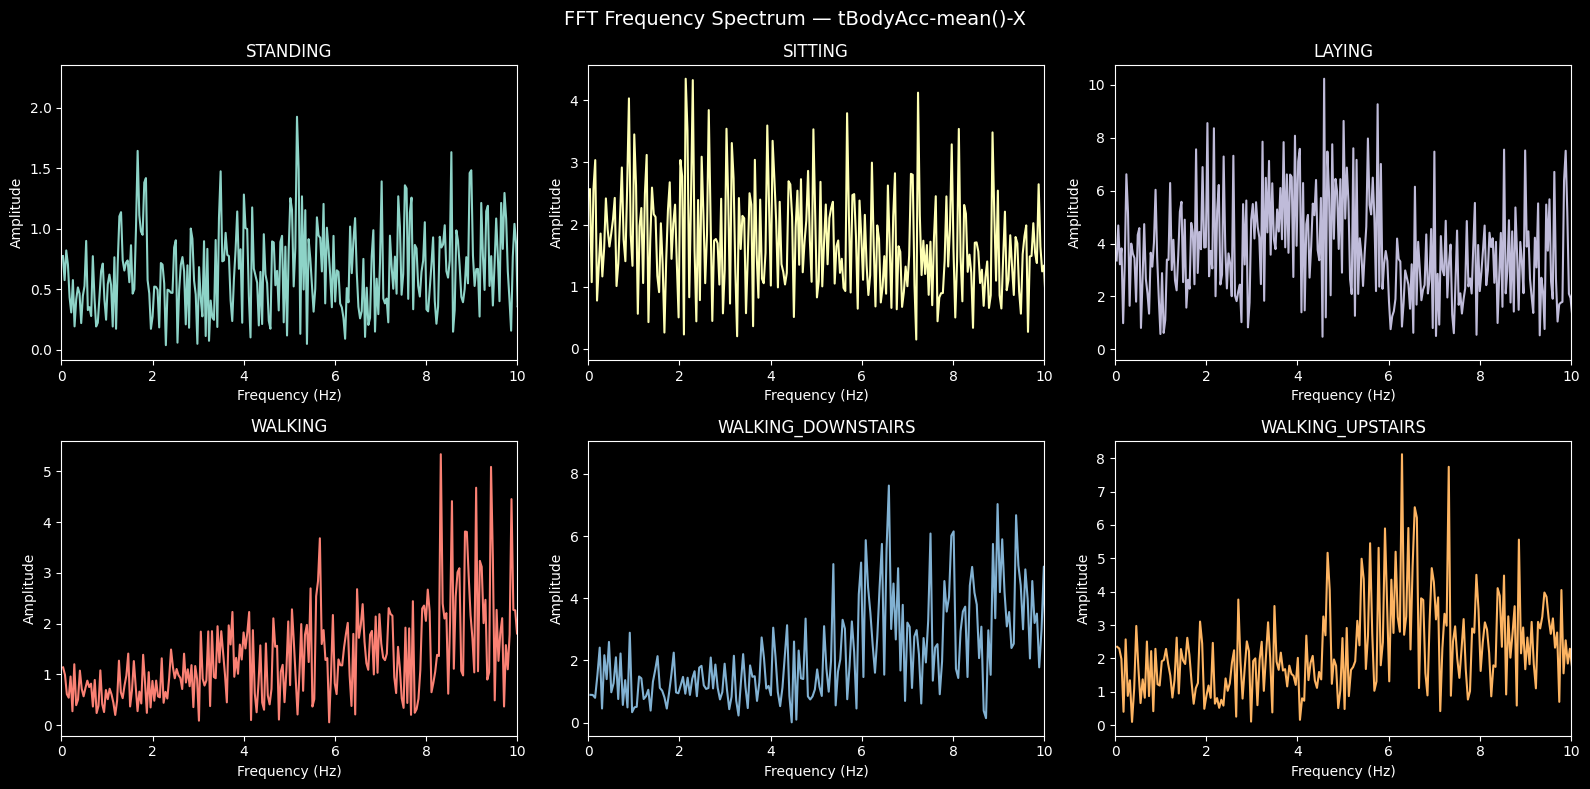

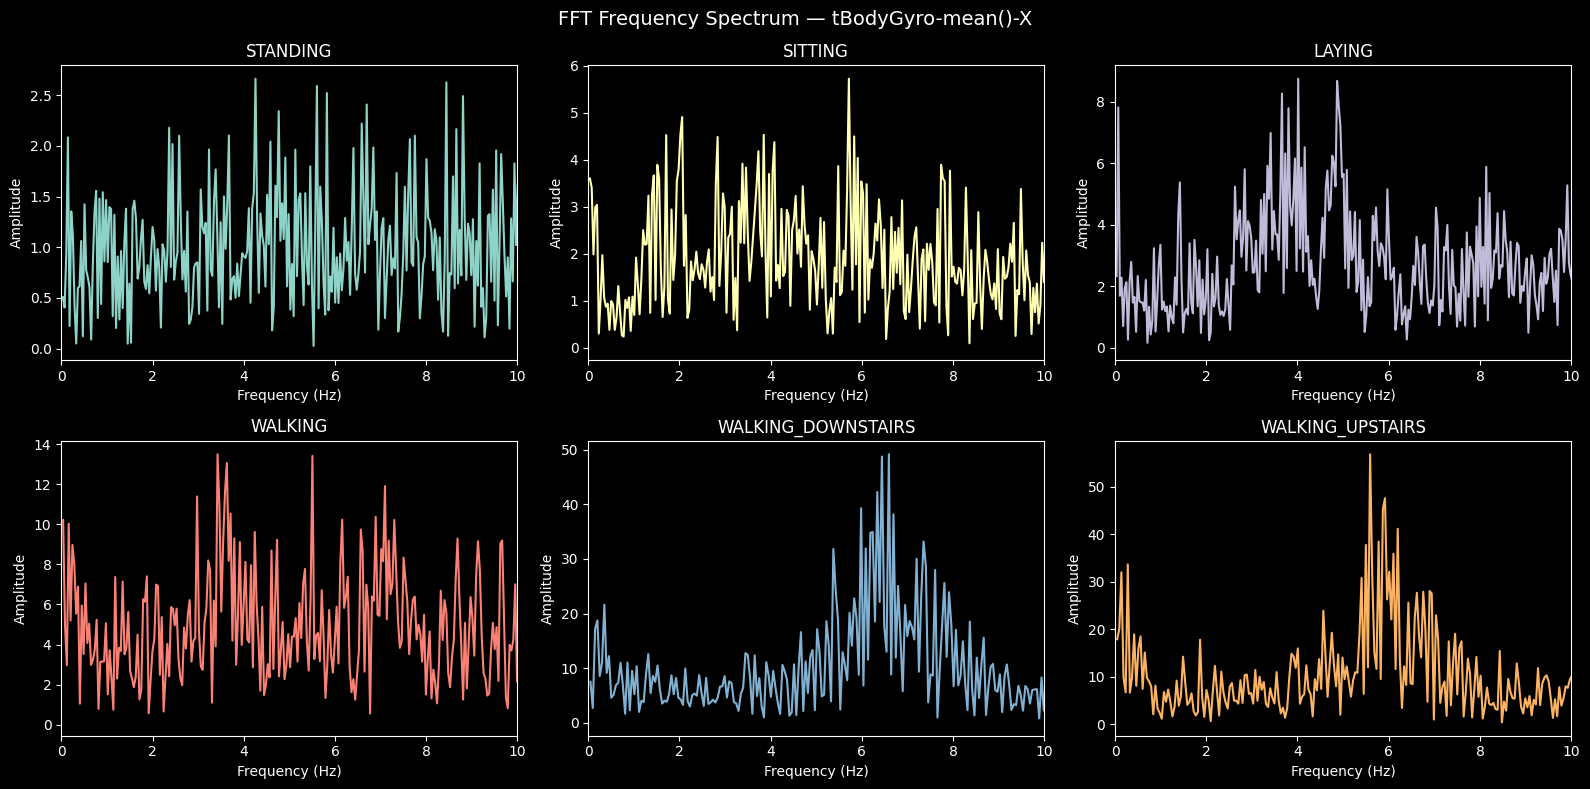

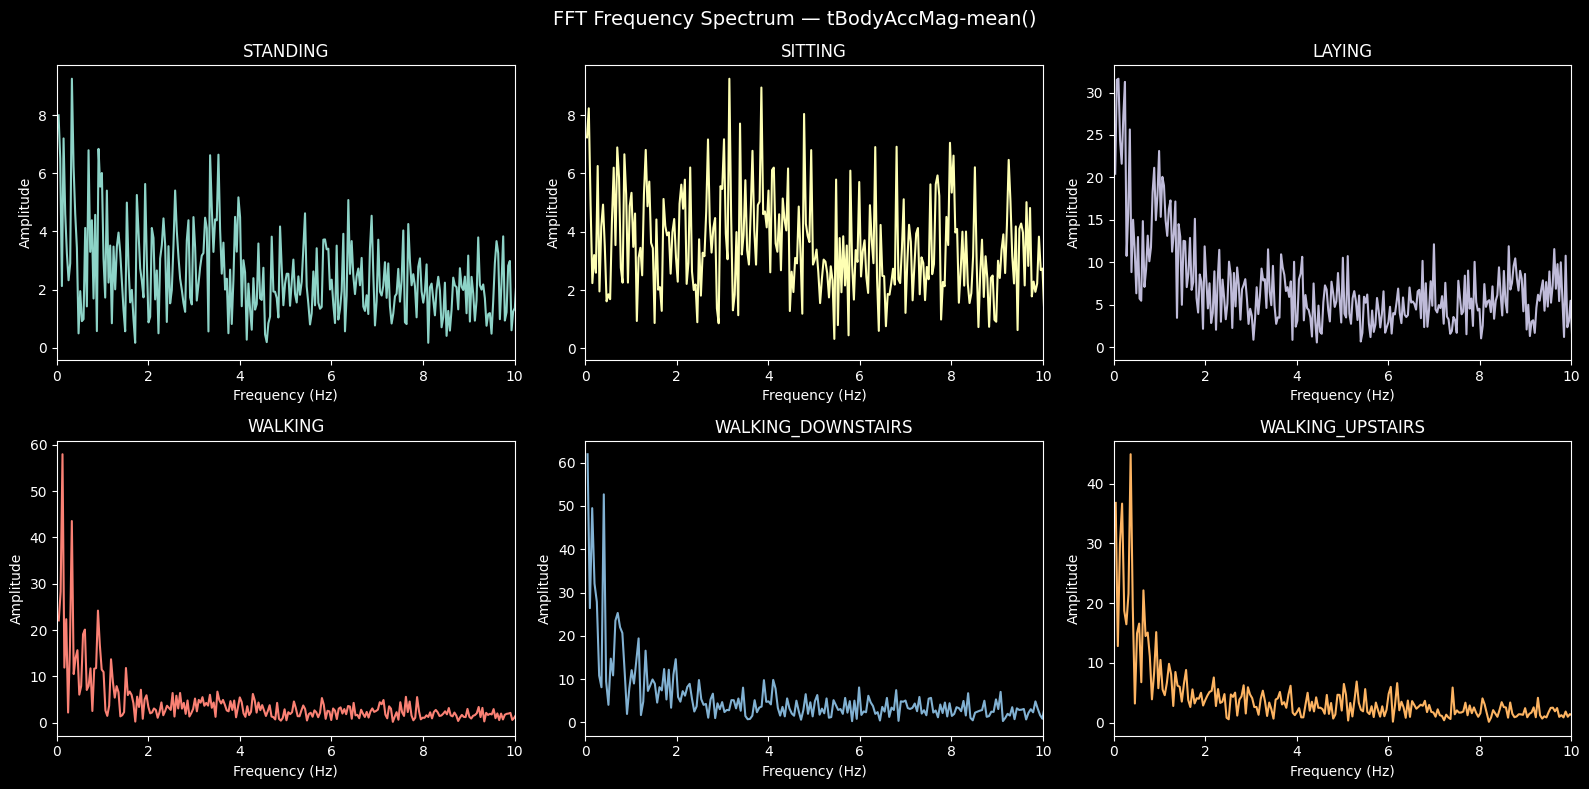

In [41]:
from numpy.fft import fft, fftfreq

feature = ['tBodyAcc-mean()-X', 'tBodyGyro-mean()-X', 'tBodyAccMag-mean()']
for j in range(len(feature)):
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()

    for i, activity in enumerate(train_df['Activity'].unique()):
        # Get signal values for this activity
        signal = train_df[train_df['Activity'] == activity][feature[j]].values

        # Apply FFT
        fft_vals = np.abs(fft(signal))        # strength of each frequency
        freqs = fftfreq(len(signal), d=1/50)  # frequency axis (50Hz rate)

        # Keep only positive frequencies
        positive = freqs > 0

        axes[i].plot(freqs[positive], fft_vals[positive], color=f'C{i}')
        axes[i].set_title(activity)
        axes[i].set_xlabel('Frequency (Hz)')
        axes[i].set_ylabel('Amplitude')
        axes[i].set_xlim(0, 10)   # focus on 0-10 Hz range

    plt.suptitle(f'FFT Frequency Spectrum — {feature[j]}', fontsize=14)
    plt.tight_layout()
    plt.show()

Class Balance Plot

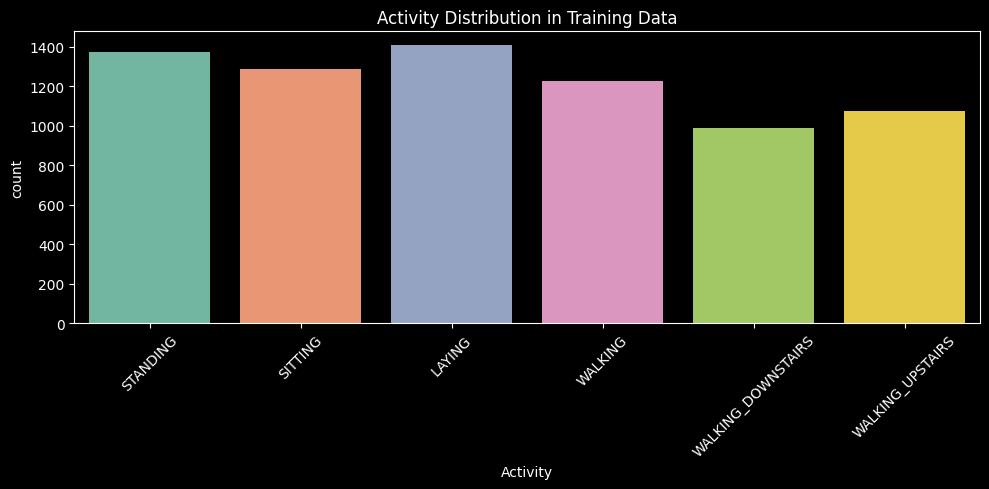

In [42]:
plt.figure(figsize=(10, 5))
sns.countplot(data=train_df, x='Activity',
              hue='Activity',
              palette='Set2',
              legend=False)
plt.title('Activity Distribution in Training Data')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Label Encoding

In [43]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print(y_train_encoded)
print(le.classes_)

[2 2 2 ... 5 5 5]
['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


# Dimensionality reduction visualization (PCA / LDA explained variance plots)

Scaling

In [44]:
X_train_clean = X_train.drop(columns=['subject'], errors='ignore')
X_test_clean  = X_test.drop(columns=['subject'], errors='ignore')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled  = scaler.transform(X_test_clean)

print("X_train shape:", X_train_clean.shape)
print("X_test shape:", X_test_clean.shape)

X_train shape: (7352, 561)
X_test shape: (2947, 561)


PCA

In [45]:
pca = PCA()
X_pca = pca.fit_transform(X_train_scaled)

# Variance explained by each component (%)
explained_var = pca.explained_variance_ratio_ * 100

# Cumulative variance
cumulative_var = np.cumsum(explained_var)

# Components needed for 95% and 99% variance
n_95 = np.argmax(cumulative_var >= 95) + 1
n_99 = np.argmax(cumulative_var >= 99) + 1

print(f"Components needed for 95% variance: {n_95}")
print(f"Components needed for 99% variance: {n_99}")

Components needed for 95% variance: 102
Components needed for 99% variance: 179


 *Scree* Plot + Cumulative Variance

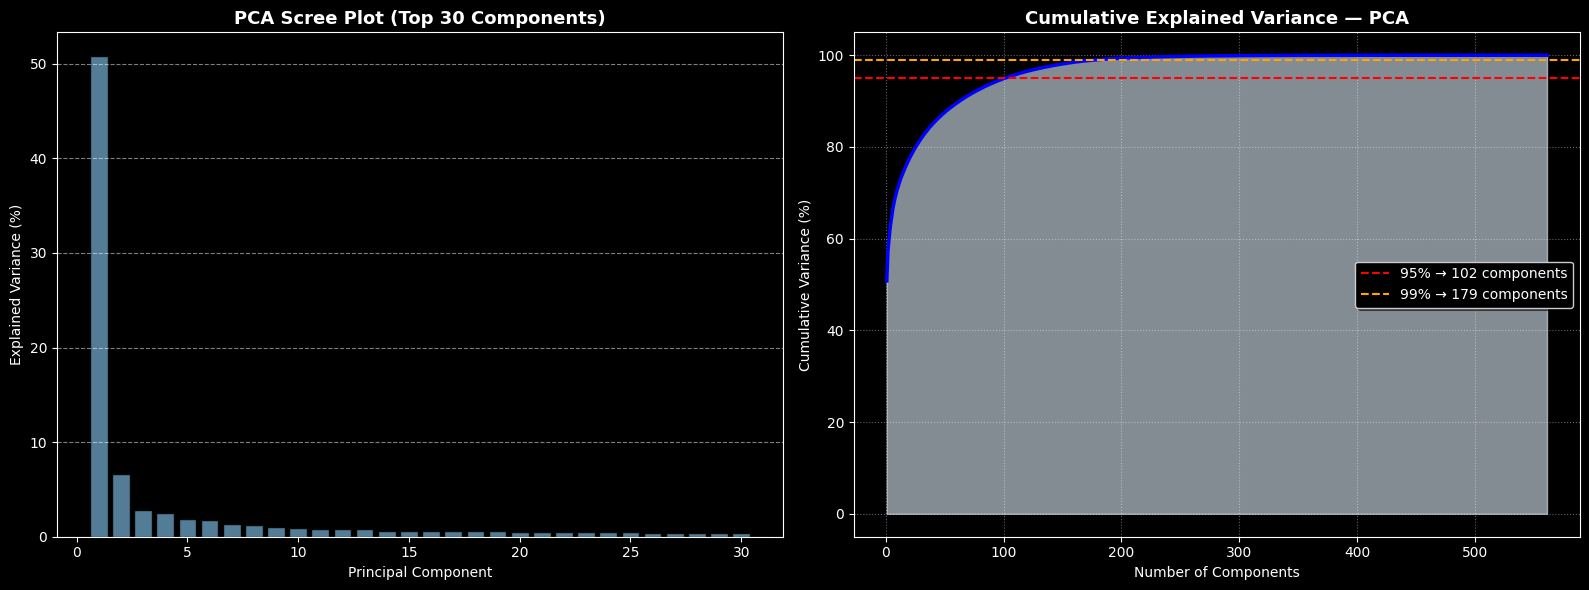

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scree Plot (Top 30 Components)
axes[0].bar(range(1, 31), explained_var[:30],
            color='#5D8AA8', edgecolor='black', alpha=0.9)
axes[0].set_title("PCA Scree Plot (Top 30 Components)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Cumulative Explained Variance
axes[1].plot(range(1, len(cumulative_var) + 1), cumulative_var, color='blue', lw=2.5)
axes[1].fill_between(range(1, len(cumulative_var) + 1), cumulative_var, color='#DEEBF7', alpha=0.6)
axes[1].axhline(y=95, color='red', linestyle='--', lw=1.5, label=f'95% → {n_95} components')
axes[1].axhline(y=99, color='orange', linestyle='--', lw=1.5, label=f'99% → {n_99} components')
axes[1].set_title("Cumulative Explained Variance — PCA", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Variance (%)")
axes[1].set_ylim(-5, 105)
axes[1].legend(loc='center right', frameon=True, shadow=True)
axes[1].grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

PCA 2D Scatter

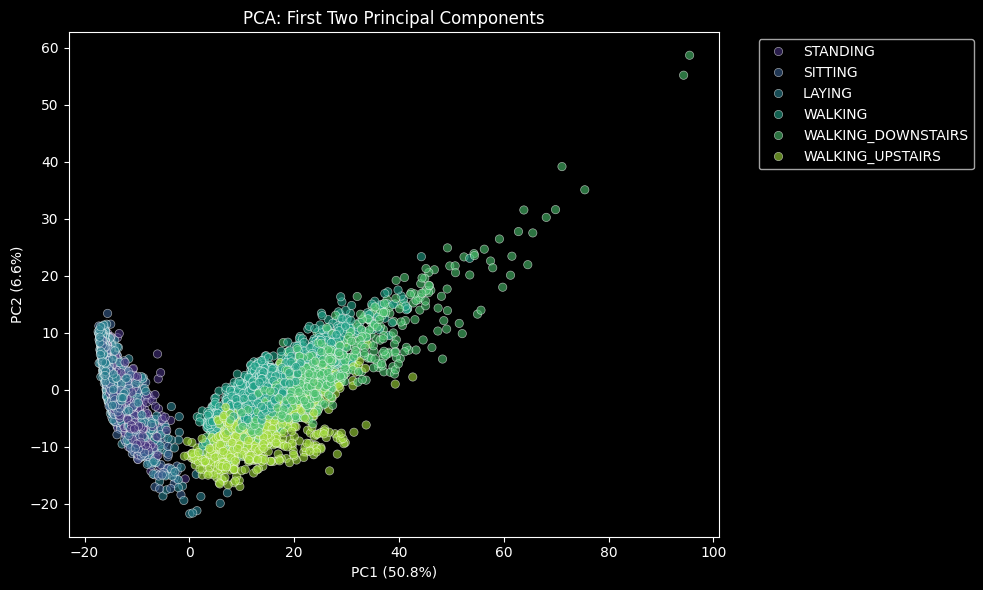

In [48]:
# Visualize first 2 PCA components
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=y_train, palette='viridis', alpha=0.6)
plt.title('PCA: First Two Principal Components')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()

 LDA 2D Scatter

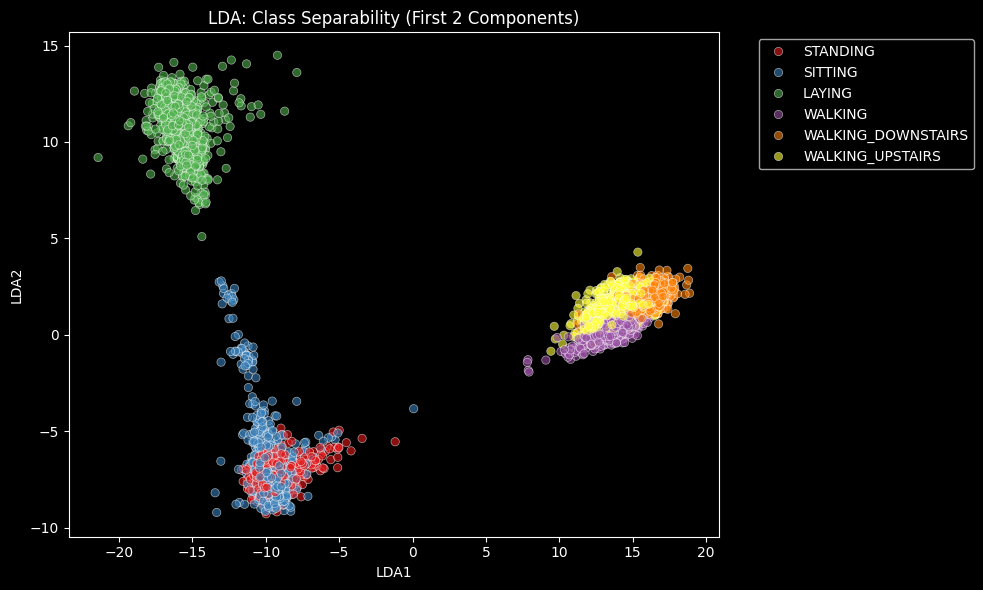

In [49]:
# Apply LDA
lda = LDA()
X_lda = lda.fit_transform(X_train_scaled, y_train_encoded)

# Visualize LDA results
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_lda[:, 0], y=X_lda[:, 1], hue=y_train, palette='Set1', alpha=0.6)
plt.title('LDA: Class Separability (First 2 Components)')
plt.xlabel('LDA1')
plt.ylabel('LDA2')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()